In [10]:
# Set up for plotting
# Params for clean and minimalistic plots

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({
    #'figure.figsize': (6*2, 2*4.5),
    'font.size': 14.0,
    'font.family': 'serif',
    'font.serif': 'Palatino',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'large',
    'legend.fontsize': 'medium',
    # dpi for high-res output
    'figure.dpi': 100,
    'savefig.dpi': 300,
    # Tight layout by default
    'figure.autolayout': True,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}[=v2]",
})

from pathlib import Path

REPO_ROOT = Path.cwd()
PLOT_ROOT = REPO_ROOT / "Plots"
DATA_ROOT = REPO_ROOT / "Data"

import numpy as np
import pandas as pd
import json

import sys 

# Add the directory to the path
sys.path.append("Ports/Python/")


In [11]:
pops, wages = [],[] # Array for the resulting L and y
max_fls_rent_C,max_fls_rent_R = [],[] # arrays that save the max floor space rent
max_S_Cs, max_S_Rs = [],[] # arras saving the 
u_rad_s= [] # Array to save the urban rad
theta_list = []

from ab2022_jit import AB2022JITModel

params = {
    'theta_C': 0.5, # 
    'theta_R': 0.55, #
    'omega_C': 0.03, #
    'omega_R': 0.07, #
    'beta_C': 0.03, #
    'a_bar_C': 2.0, #
    'a_bar_R': 1.0, #
    'tau_C': 0.01, #
    'tau_R': 0.005, #
    'c_C': 1.4, #
    'c_R': 1.4, #   
    'r_a': 30.0, #
    'S_bar_C': 999.0, # No building heigh penalty
    'S_bar_R': 999.0, # No building heigh penalty
    # alpha values from Stata code
    'alpha_C': 0.85, # 1- alpha_c = 0.15
    'alpha_R': 0.67, # 1 - alpha_r= 0.33
    'beta_R': 0.0 # not specified
} # Parameters Finished

as_bar_C = np.arange(2, 6, 0.01)

df_a = AB2022JITModel.run_parallel_sweep('a_bar_C', as_bar_C, params)
data_to_save = {key: df_a[key].tolist() for key in df_a.keys()}

with open(Path.cwd() / "Data" / "task_4_1_data.json", "w") as f:
    json.dump(data_to_save, f, indent=4)

In [12]:
pops, wages = [],[] # Array for the resulting L and y
max_fls_rent_C,max_fls_rent_R = [],[] # arrays that save the max floor space rent
max_S_Cs, max_S_Rs = [],[] # arras saving the 
u_rad_s= [] # Array to save the urban rad
theta_list = []

from ab2022_jit import AB2022JITModel

params = {
    'theta_C': 0.5, # 
    'theta_R': 0.55, #
    'omega_C': 0.03, #
    'omega_R': 0.07, #
    'beta_C': 0.03, #
    'a_bar_C': 2.0, #
    'a_bar_R': 1.0, #
    'tau_C': 0.01, #
    'tau_R': 0.005, #
    'c_C': 1.4, #
    'c_R': 1.4, #   
    'r_a': 30.0, #
    'S_bar_C': 999.0, # No building heigh penalty
    'S_bar_R': 999.0, # No building heigh penalty
    # alpha values from Stata code
    'alpha_C': 0.85, # 1- alpha_c = 0.15
    'alpha_R': 0.67, # 1 - alpha_r= 0.33
    'beta_R': 0.0 # not specified
} # Parameters Finished

as_bar_R = np.arange(2, 6, 0.01)

df_b = AB2022JITModel.run_parallel_sweep('a_bar_R', as_bar_R, params)
data_to_save = {key: df_b[key].tolist() for key in df_b.keys()}

with open(Path.cwd() / "Data" / "task_4_2_data.json", "w") as f:
    json.dump(data_to_save, f, indent=4)

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import json
from pathlib import Path

# ── 0. Paths ──────────────────────────────────────────────────────────────────
DATA_ROOT = Path("Data")

# ── 1. Load data ──────────────────────────────────────────────────────────────
#
# task_4_1_data.json  — sweep over a_bar_C  (part a)
# task_4_2_data.json  — sweep over a_bar_R  (part b)
#
# If task_4_2_data.json does not yet exist, run the sweep block below first.

def load_city_panel(path):
    """
    Extract cross-city panel: one row per valid (L > 0) artificial city.
    Returns DataFrame with columns [run, param_value, lnL, lny].
    """
    with open(path) as f:
        d = json.load(f)
    L   = np.array(d["L"],            dtype=float)
    y   = np.array(d["y"],            dtype=float)
    pv  = np.array(d["param_values"], dtype=float)
    valid = L > 0
    return pd.DataFrame({
        "run":         np.where(valid)[0],
        "param_value": pv[valid],
        "lnL":         np.log(L[valid]),
        "lny":         np.log(y[valid]),
    })

df_a = load_city_panel(DATA_ROOT / "task_4_1_data.json")

'''# ── [Optional] Generate task_4_2_data.json if it doesn't exist ───────────────
if not (DATA_ROOT / "task_4_2_data.json").exists():
    print("task_4_2_data.json not found — running a_bar_R sweep …")
    import sys
    sys.path.append("Ports/Python/")
    from ab2022_jit import AB2022JITModel

    params_b = {
        'theta_C': 0.5,   'theta_R': 0.55,
        'omega_C': 0.03,  'omega_R': 0.07,
        'beta_C':  0.03,  'beta_R':  0.0,
        'a_bar_C': 2.0,   'a_bar_R': 1.0,    # a_bar_C fixed here
        'tau_C':   0.01,  'tau_R':   0.005,
        'c_C':     1.4,   'c_R':     1.4,
        'r_a':     30.0,
        'S_bar_C': 999.0, 'S_bar_R': 999.0,
        'alpha_C': 0.85,  'alpha_R': 0.67,
    }
    as_bar_R = np.arange(0, 4, 0.1)
    data_b = AB2022JITModel.run_parallel_sweep('a_bar_R', as_bar_R, params_b)
    with open(DATA_ROOT / "task_4_2_data.json", "w") as f:
        json.dump({k: v.tolist() for k, v in data_b.items()}, f, indent=4)
    print("  → saved task_4_2_data.json")'''

df_b = load_city_panel(DATA_ROOT / "task_4_2_data.json")

print(f"Part (a): {len(df_a)} cities (a_bar_C sweep), "
      f"lnL ∈ [{df_a['lnL'].min():.2f}, {df_a['lnL'].max():.2f}]")
print(f"Part (b): {len(df_b)} cities (a_bar_R sweep), "
      f"lnL ∈ [{df_b['lnL'].min():.2f}, {df_b['lnL'].max():.2f}]")

# ── 2. Cross-city OLS: ln(y_i) = α + γ·ln(L_i) + ε_i ────────────────────────
#
# Structural equation:
#   ln y_i = β_C · ln L_i + ln ā_C^(i) + GE terms
#
# Estimating equation (both parts):
#   ln y_i = α + γ · ln L_i + ε_i
#
# Part (a): ā_C varies → ln(ā_C) enters both y and L → OVB pushes γ̂ >> β_C
# Part (b): ā_R varies → ā_R ∉ wage equation → γ̂ ≈ β_C (clean identification)

BETA_C = 0.03   # structural agglomeration elasticity (from params dict)

def agglomeration_ols(df, label, sweep_param):
    """
    OLS of ln(y) on ln(L) across artificial cities.
    N = number of cities (one obs per run with L > 0).
    HC3 heteroskedasticity-robust SEs (small N cross-section).
    """
    X = sm.add_constant(df["lnL"])
    res = sm.OLS(df["lny"], X).fit(cov_type="HC3")

    gamma_hat = res.params["lnL"]
    bias      = gamma_hat - BETA_C

    print(f"\n{'═'*62}")
    print(f"  Task 4{label} — agglomeration elasticity  γ = d ln y / d ln L")
    print(f"  Sweep parameter: {sweep_param}")
    print(f"{'═'*62}")
    print(f"  N cities        = {len(df)}")
    print(f"  Estimated  γ̂   = {gamma_hat:.4f}  "
          f"(SE = {res.bse['lnL']:.4f})")
    print(f"  Structural β_C  = {BETA_C:.4f}")
    print(f"  Bias  (γ̂−β_C)  = {bias:+.4f}")
    print(f"  R²              = {res.rsquared:.4f}")
    print(res.summary())
    return res

res_a = agglomeration_ols(df_a, "(a)", "a_bar_C  [productivity fundamental]")
res_b = agglomeration_ols(df_b, "(b)", "a_bar_R  [amenity fundamental]")

# ── 3. OVB decomposition (part a) ────────────────────────────────────────────
#
# True model:  ln y  =  β_C · ln L  +  δ · ln ā_C  +  const
# OVB formula: γ̂_a  =  β_C  +  δ · b_{ā_C, L}
#   where b_{ā_C, L} = Cov(ln ā_C, ln L) / Var(ln L)   [auxiliary regression]
#
# ln ā_C is the exogenous driver — we observe param_value directly.

df_a["ln_param"] = np.log(df_a["param_value"])
aux = sm.OLS(df_a["ln_param"], sm.add_constant(df_a["lnL"])).fit()
b_aux = aux.params["lnL"]

# Estimate δ: regress ln y on ln L AND ln ā_C (long regression)
X_long = sm.add_constant(df_a[["lnL", "ln_param"]])
res_long = sm.OLS(df_a["lny"], X_long).fit(cov_type="HC3")
delta = res_long.params["ln_param"]
beta_C_long = res_long.params["lnL"]

print(f"\n{'─'*62}")
print(f"  OVB decomposition for part (a):")
print(f"{'─'*62}")
print(f"  Long regression (controls for ln ā_C):")
print(f"    β̂_C (long)  = {beta_C_long:.4f}   ← should recover {BETA_C}")
print(f"    δ̂           = {delta:.4f}   (wage elasticity w.r.t. ā_C | L)")
print(f"  Auxiliary: b_{{ā_C, L}} = {b_aux:.4f}")
print(f"  OVB = δ̂ × b_{{ā_C,L}}  = {delta * b_aux:.4f}")
print(f"  Short γ̂_a              = {res_a.params['lnL']:.4f}")
print(f"  Check: β_C + OVB       = {BETA_C + delta * b_aux:.4f}")

# ── 4. Summary ────────────────────────────────────────────────────────────────
print("\n── Summary ──────────────────────────────────────────────────────────")
print(f"  Structural β_C                   = {BETA_C:.4f}")
print(f"  (a) γ̂  [ā_C sweep, OLS]          = {res_a.params['lnL']:.4f}  "
      f"→ UPWARD BIAS  Δ = {res_a.params['lnL'] - BETA_C:+.4f}")
print(f"  (b) γ̂  [ā_R sweep, OLS]          = {res_b.params['lnL']:.4f}  "
      f"→ ≈ UNBIASED    Δ = {res_b.params['lnL'] - BETA_C:+.4f}")
print()
print("── Part (c) interpretation ──────────────────────────────────────────")
print("  In observational data, cities vary in both ā_C and ā_R.")
print("  OLS estimates a weighted combination of cases (a) and (b).")
print("  Productivity-driven size variation (ā_C type) inflates γ̂ above β_C.")
print("  Amenity-driven size variation (ā_R type) recovers β_C.")
print()
print("  → Valid instruments for N_i must exploit ā_R-type variation:")
print("    geographic amenities, land constraints (Saiz 2010),")
print("    historical settlement — NOT industry-based (Bartik) shocks.")
print("  → Bartik/shift-share instruments reflect ā_C-type productivity shocks")
print("    → violate the exclusion restriction for identifying β_C.")

Part (a): 400 cities (a_bar_C sweep), lnL ∈ [14.67, 20.61]
Part (b): 400 cities (a_bar_R sweep), lnL ∈ [20.09, 23.18]

══════════════════════════════════════════════════════════════
  Task 4(a) — agglomeration elasticity  γ = d ln y / d ln L
  Sweep parameter: a_bar_C  [productivity fundamental]
══════════════════════════════════════════════════════════════
  N cities        = 400
  Estimated  γ̂   = 0.1520  (SE = 0.0019)
  Structural β_C  = 0.0300
  Bias  (γ̂−β_C)  = +0.1220
  R²              = 0.9466
                            OLS Regression Results                            
Dep. Variable:                    lny   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     6504.
Date:                Fri, 15 May 2026   Prob (F-statistic):          1.07e-248
Time:                        13:18:37   Log-Likelihood:                 567.32
No. Observations: 

In [14]:
print(res_a.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &       lny        & \textbf{  R-squared:         } &     0.947   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.946   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     6504.   \\
\textbf{Date:}             & Fri, 15 May 2026 & \textbf{  Prob (F-statistic):} & 1.07e-248   \\
\textbf{Time:}             &     13:18:37     & \textbf{  Log-Likelihood:    } &    567.32   \\
\textbf{No. Observations:} &         400      & \textbf{  AIC:               } &    -1131.   \\
\textbf{Df Residuals:}     &         398      & \textbf{  BIC:               } &    -1123.   \\
\textbf{Df Model:}         &           1      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &       HC3        & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
               & \textbf{coef} & \textb

In [15]:
print(res_b.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &       lny        & \textbf{  R-squared:         } &     0.997   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.997   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } & 4.346e+04   \\
\textbf{Date:}             & Fri, 15 May 2026 & \textbf{  Prob (F-statistic):} &     0.00    \\
\textbf{Time:}             &     13:18:37     & \textbf{  Log-Likelihood:    } &    1580.4   \\
\textbf{No. Observations:} &         400      & \textbf{  AIC:               } &    -3157.   \\
\textbf{Df Residuals:}     &         398      & \textbf{  BIC:               } &    -3149.   \\
\textbf{Df Model:}         &           1      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &       HC3        & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
               & \textbf{coef} & \textb

In [16]:
# Load again df_a and df_b
with open(DATA_ROOT / "task_4_1_data.json", "r") as f:
    data_a = json.load(f)
with open(DATA_ROOT / "task_4_2_data.json", "r") as f:
    data_b = json.load(f)

In [17]:
data_a['y']

[2.3159430977201243,
 2.3270075986446654,
 2.33811778220773,
 2.3492012923874803,
 2.3602742933757193,
 2.371334171208618,
 2.382378523189203,
 2.393469096302334,
 2.4044740191529015,
 2.4155679106777033,
 2.4266351930003918,
 2.43768626950268,
 2.4487192978183305,
 2.4597531057815085,
 2.4707896126634745,
 2.4818228110225125,
 2.492853663975795,
 2.503882240568124,
 2.5149085468899868,
 2.5259326049937725,
 2.5369544349678925,
 2.5479740460017632,
 2.5589914496787376,
 2.5700066530678676,
 2.5810196717317293,
 2.592030500936742,
 2.603039163493992,
 2.6140456695834073,
 2.625050028430512,
 2.6360522508376896,
 2.6470523460805735,
 2.6580503237555337,
 2.6690461931880485,
 2.680043044327308,
 2.691034764199508,
 2.7020244043333044,
 2.713011973577647,
 2.7239974810215757,
 2.734980935737722,
 2.7459623465567216,
 2.7569417227624804,
 2.7679190729866985,
 2.7788944055909743,
 2.789867730104839,
 2.800839054654169,
 2.811808387905292,
 2.822775738337575,
 2.8337411142922715,
 2.844704523

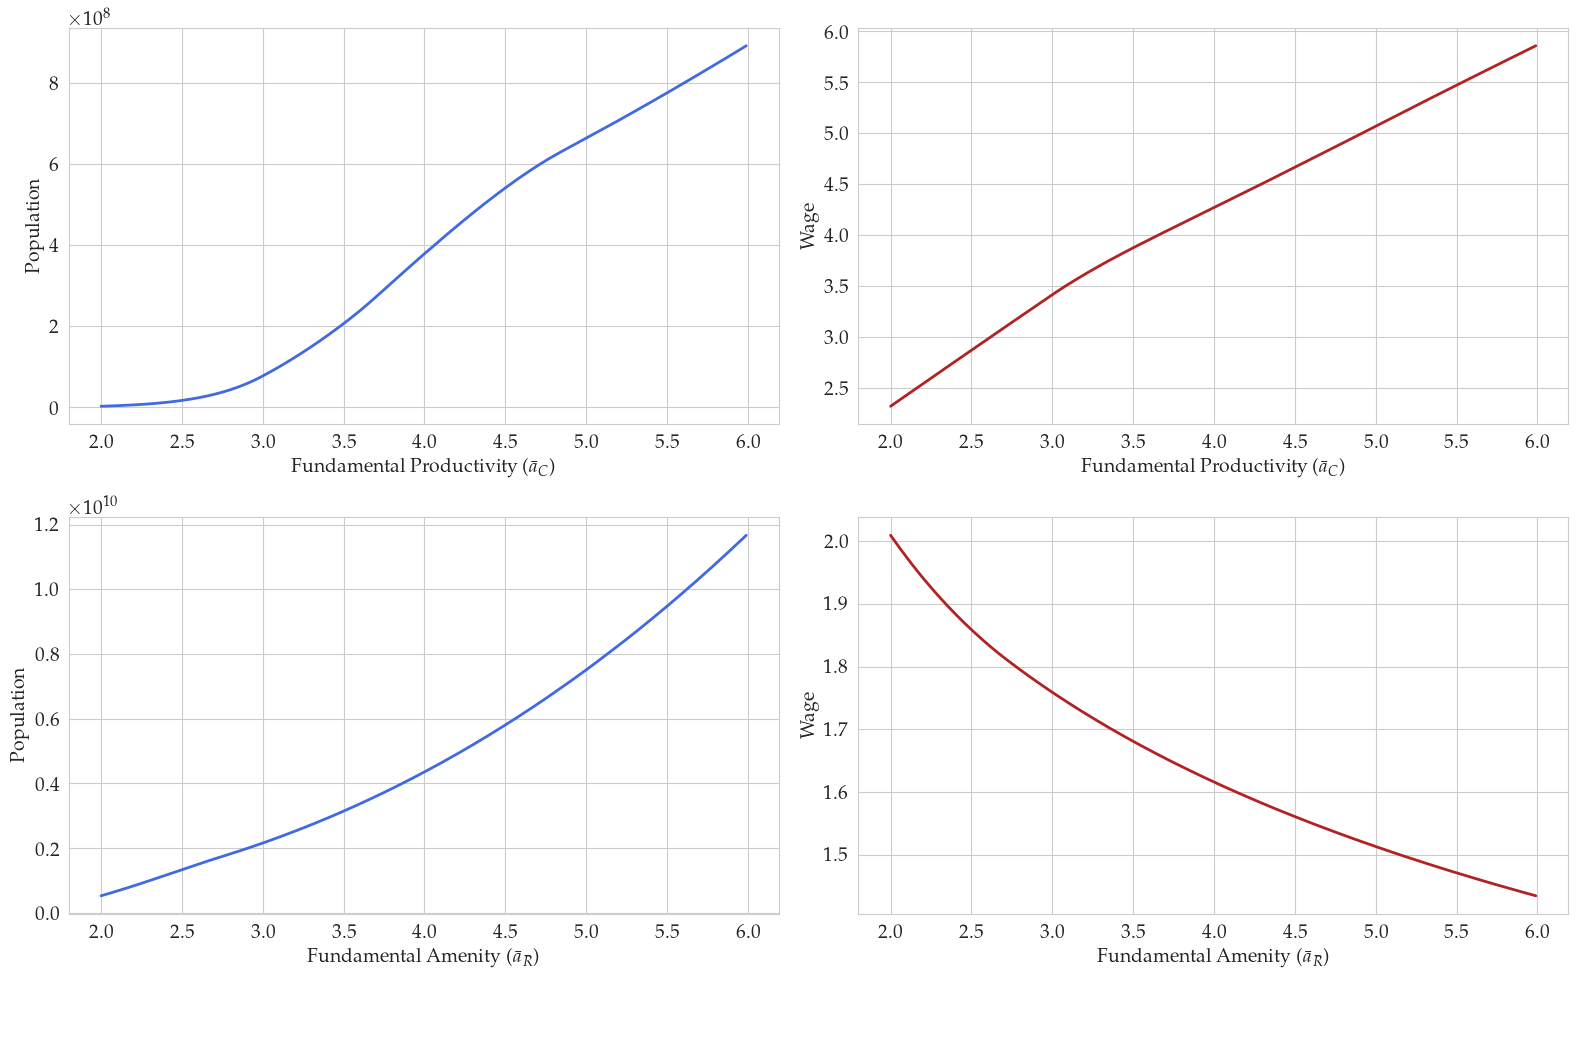

In [18]:
# Plot changes in y and L across the sweep of a_bar_C and a_bar_R, respectively.
# Plot matrix 2 x 2 with ln y or ln L on the y axes, and values of a_bar_C or a_bar_R on the x axes, respectively.

import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# --- ROW 0: Agglomeration Elasticity ---
label_x0 = r"Fundamental Productivity ($\bar{a}_C$)"

axs[0, 0].plot(data_a['param_values'], data_a['L'], color = "royalblue", linewidth=2)
axs[0, 0].set_xlabel(label_x0)
axs[0, 0].set_ylabel("Population")

axs[0, 1].plot(data_a['param_values'], data_a['y'], color = "firebrick", linewidth=2)
axs[0, 1].set_xlabel(label_x0)
axs[0, 1].set_ylabel("Wage")

# --- ROW 1: Population ---
label_x1 = r"Fundamental Amenity ($\bar{a}_R$)"

axs[1, 0].plot(data_b['param_values'], data_b['L'], color = "royalblue", linewidth=2)
axs[1, 0].set_xlabel(label_x1)
axs[1, 0].set_ylabel("Population")

# Fixed the duplicate labels and color logic here
axs[1, 1].plot(data_b['param_values'], data_b['y'], color = "firebrick", linewidth=2)
axs[1, 1].set_ylabel("Wage")
axs[1, 1].set_xlabel(label_x1)

# Collect unique legend items from all subplots
handles, labels = axs[0, 1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Create single legend at the bottom
fig.legend(by_label.values(), by_label.keys(), loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), frameon=False)

# Final layout polish
plt.tight_layout()
plt.savefig(PLOT_ROOT / "task_4_1.png", bbox_inches='tight', dpi=300)
plt.show()
